In [2]:
# Necessary imports
%env CUDA_VISIBLE_DEVICES = 4
import os
import sys
sys.path.insert(0, "../../batchflow")

import warnings
from functools import partial
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
plt.style.use('ggplot')


from batchflow import B, M, P, R, V, Notifier, Pipeline
from batchflow import set_gpus
from batchflow.plotter import plot
from batchflow.models.torch import TorchModel
from batchflow.models.torch.unet import UNet
from batchflow.models.torch.losses import CrossEntropyLoss
from batchflow.models.torch.blocks import BottleneckBlock
from batchflow.opensets.pascal import PascalSegmentation
from batchflow.opensets.coco import COCOSegmentation
from batchflow.opensets import PascalSegmentation
from batchflow import Batch, Pipeline, B, V, C, apply_parallel, ImagesBatch, action

from nbtools import pylint_notebook
from batchflow.opensets import ImagesOpenset

env: CUDA_VISIBLE_DEVICES=4


In [ ]:
!nvidia-smi

Wed Mar  8 08:41:54 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 520.56.06    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 27%   23C    P8     1W / 260W |   5753MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1B:00.0 Off |                  N/A |
| 27%   

### Load Pascal dataset 

In [3]:
dataset = PascalSegmentation()
len(dataset.train), len(dataset.test)

(1464, 1449)

In [4]:
dataset.split(shares=0.9, shuffle=1)

In [5]:
len(dataset.train), len(dataset.test)

(2622, 291)

In [38]:
# Set Gloabal Parameters
IMAGE_SHAPE = (256, 256)

NUM_EPOCHS = 70
FREQUENCY = 10
BATCH_SIZE = 16

NUM_CLASSES = len(dataset.classes)
NUM_CLASSES

21

### Set the model 

In [43]:
config = {
    'inputs_shapes': (3, *IMAGE_SHAPE),
          'head': {
                'layout': 'c',
                'channels': NUM_CLASSES,
                'kernel_size': 1,
                'stride': 1,
                'padding': 0 
            },
          'device': 'cuda:0',
          'loss': CrossEntropyLoss(ignore_index=0),
          'optimizer': {'name': 'Adam', 'lr': 1e-4}
}

In [31]:
train_config = 'unet_final.torch' # config for loading the model 

### Form the train pipeline 

In [32]:
def squeeze_batch(batch):
    return batch.squeeze(1)

def change_background(batch):
    batch.my_labels[batch.my_labels == 255] = 0
    return batch

def to_tensor(batch):
   
    batch = torch.from_numpy(batch).to(dtype=torch.long)
    return batch

In [46]:
load_pipeline = (
    Pipeline()
    .resize(size=IMAGE_SHAPE, src='images', dst='images')
    .resize(size=IMAGE_SHAPE, src='labels', dst='my_labels')
    .to_array(channels='first', src='images', dst='images', dtype=np.float32)
    .to_array(channels=None, src='my_labels', dst='my_labels', dtype=np.float32)
    .change_background(B())
    #.squeeze_batch(B())
    .multiply(multiplier=1/255, src='images')
)

augmentations_pipeline = (
    Pipeline()
    #.scale(factor=10, src=['images', 'labels'], dst=['images', 'labels'], preserve_shape=True, p=1) # P(R('uniform', 0.5, 1, size=1))
    #.flip(mode=P(R(['lr', 'ud'])), src=['images', 'labels'], dst=['images', 'labels'], p=0.5)
    #.rotate(angle=P(R([90, 60])), src=['images', 'labels'], dst=['images', 'labels'], p=0.5)
    #.crop(origin='top_left', shape=(100, 100), src=['images', 'labels'], dst=['images', 'labels'])
)

train_model_pipeline = (
    Pipeline()
    .init_model('unet', model_class=UNet, mode='dynamic', config=train_config) # load model 
    .init_variable('train_loss', [])
    #.print(B('my_labels'))
    .train_model('unet', inputs=B('images'), targets=B('my_labels'), outputs='loss', save_to=V('train_loss', mode='a'))
)

main_pipeline = (augmentations_pipeline + load_pipeline + train_model_pipeline) << dataset.train

### Plot images from the pipeline

In [36]:
batch = main_pipeline.next_batch(4, shuffle=True)
images = batch.images.transpose((0, 2, 3, 1))
masks = batch.my_labels
images.shape

(4, 256, 256, 3)

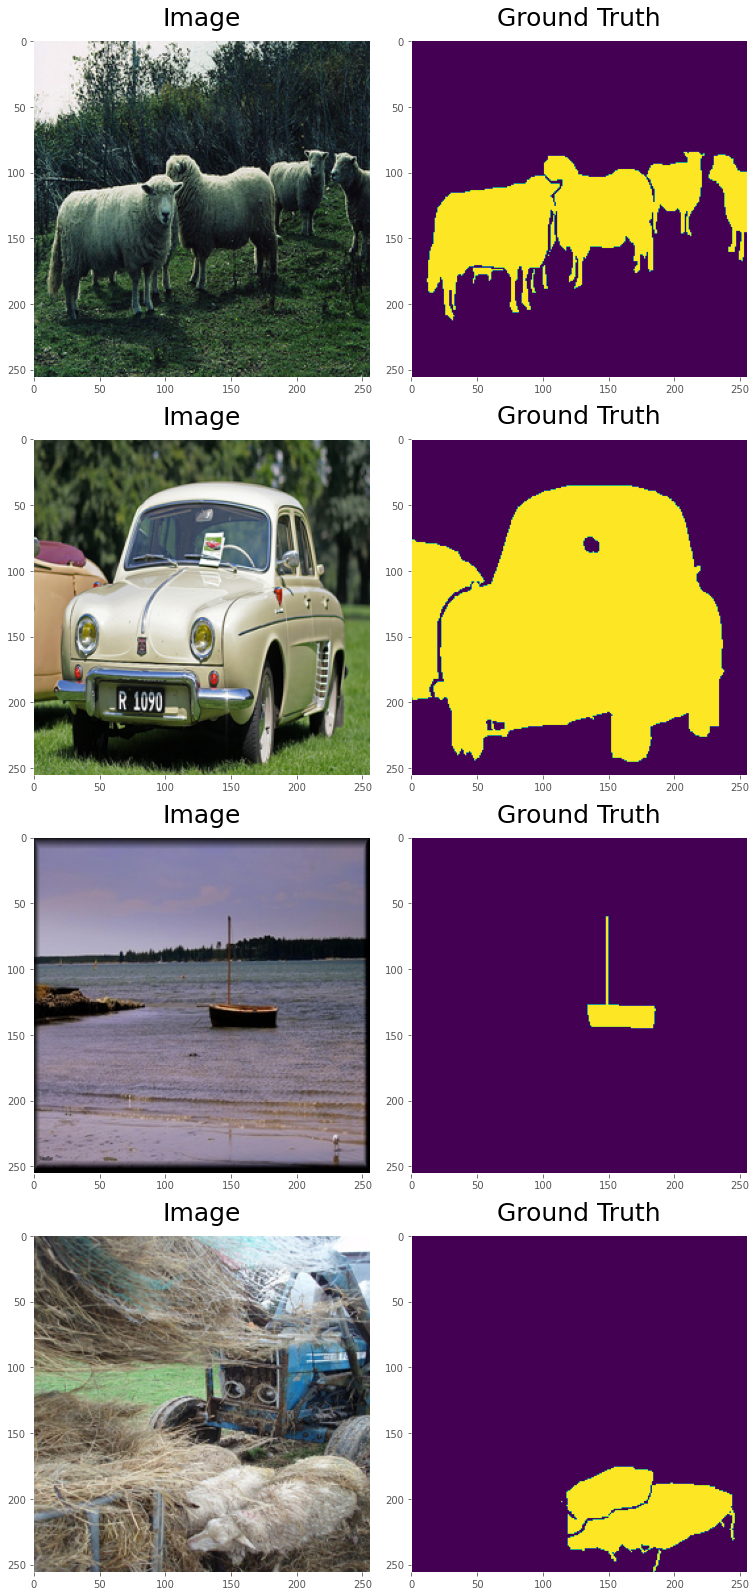

In [11]:
all_images = []

for i in range(len(images)):
    all_images.extend((images[i], masks[i]))
    
plot(all_images, title=['Image', 'Ground Truth'] * len(images), combine='separate', cmap='viridis', ncols=2, figsize=(10, 20))

### Training model

Validation pipeline for training loop

In [47]:
metrics_pipeline = (
     Pipeline()
    .import_model('unet', main_pipeline)
    #.load_model(name='unet', model_class=UNet, path='unet_final.torch')
    #.init_model(name='unet', model_class=UNet, config=config)
    .init_variable('metrics')
    #.init_variable('iou')
    .init_variable('predicted_masks')
    .init_variable('val_loss', [])
    .predict_model('unet',
                   inputs=B('images'),
                   targets=B('my_labels'),
                   outputs=['predictions', 'loss'],
                   save_to=[V('predicted_masks', mode='w'), V('val_loss', mode='a')]
                  )
    .gather_metrics('segmentation',
                    targets=B('my_labels'),
                    predictions=V('predicted_masks'),
                    fmt='logits',
                    num_classes=NUM_CLASSES,
                    axis=1, # ????
                    save_to=V('metrics', mode='u')
                    )
)

val_pipeline = (load_pipeline + metrics_pipeline) << dataset.train

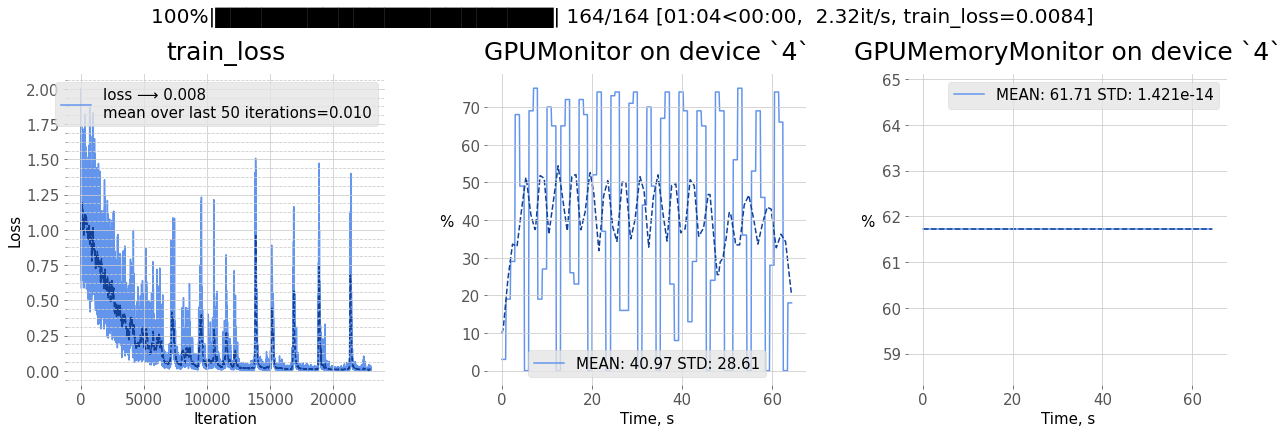

100%|█████████████████████████████████████████| 163/163 [01:57<00:00,  1.39it/s]


In [56]:
if not os.path.exists('logs'):
    os.mkdir('logs')
    
val_loss_history = [3] 
metrics_history = [0]
min_val_loss = np.inf 

train_notifier = {
    'bar': 'n',
    'frequency': FREQUENCY,
    'graphs': [
        {'source': 'train_loss'},
        #{'source': val_loss_history, 
        # 'name': 'val_loss'},
        #{'source': metrics_history, 
        # 'name': 'IoU'},
        {'source': 'gpu'},
        {'source': 'gpu_memory'}
    ],
    #'graphs': ['train_loss', 'val_loss', 'gpu'],
    'savepath': './logs/notifier'
}

for _ in range(NUM_EPOCHS):
    main_pipeline.run(batch_size=BATCH_SIZE, n_epochs=1, shuffle=True, notifier=train_notifier)
    # load_model_now()
    val_pipeline.run(batch_size=BATCH_SIZE, drop_last=True, bar='t')
    iou = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='macro')
    metrics_history.append(iou)
    val_loss = np.mean(val_pipeline.v('val_loss'))
    val_loss_history.append(val_loss)
    #main_pipeline.set_variable('val_loss', val_loss, mode='a')
    
    if val_loss < min_val_loss:
        main_pipeline.save_model_now('unet', path='unet_final.torch')
        min_val_loss = val_loss

### Inference 

In [50]:
val_pipeline.run(batch_size=BATCH_SIZE, drop_last=False, bar='t')

IoU_micro = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='micro')
IoU_macro = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='macro')
IoU_per_class = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass=None)

100%|█████████████████████████████████████████| 164/164 [01:37<00:00,  1.68it/s]


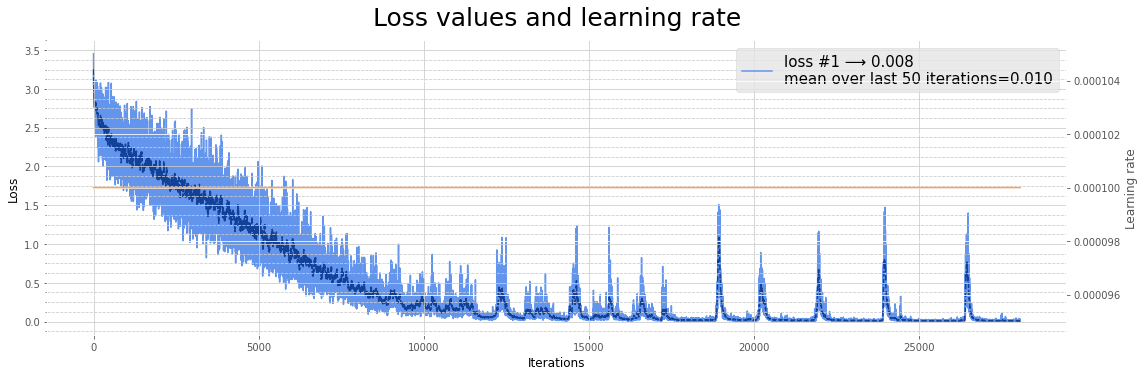

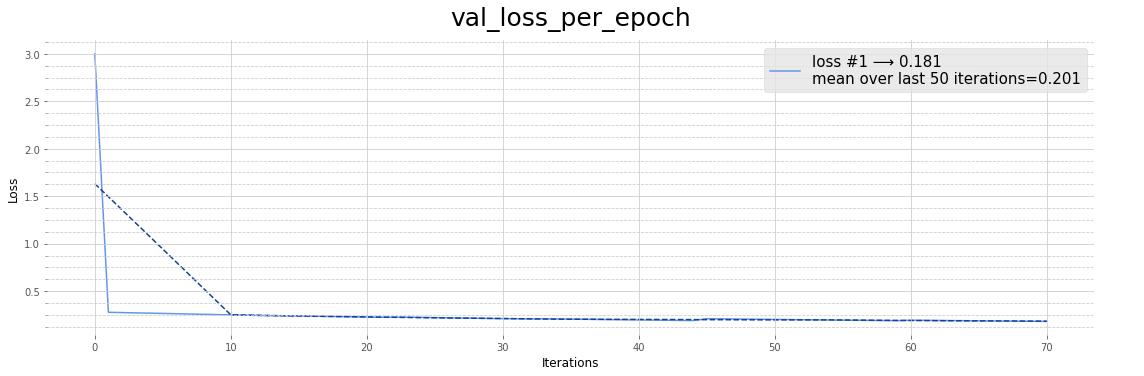

In [57]:
main_pipeline.model.plot_loss()
plot(val_loss_history, mode='loss', title='val_loss_per_epoch')

In [58]:
print(IoU_micro)
print(IoU_macro)
print(IoU_per_class)

0.15080770302225482
0.06470330040891341
[0.00741674 0.03437452 0.01562518 0.03628274 0.02544466 0.0254875
 0.04310168 0.04839477 0.06268638 0.0252334  0.02816283 0.04130067
 0.05363288 0.03316673 0.04271642 0.11208277 0.02459595 0.02434417
 0.0338437  0.03775516 0.0278481 ]


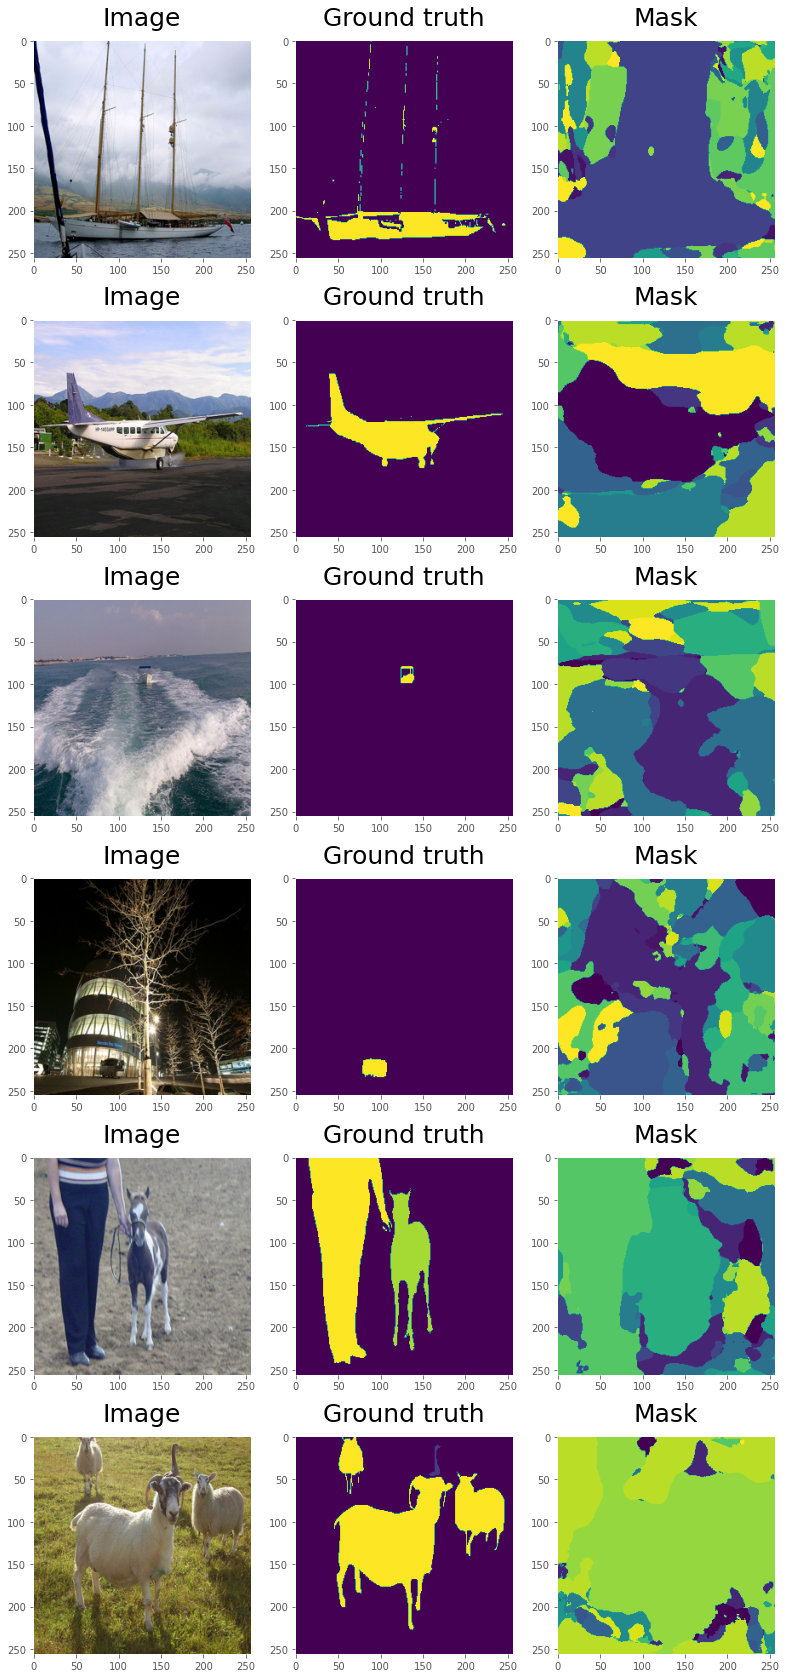

In [59]:
#val_pipeline.reset('iter')
#val_pipeline.load_model_now(name='unet', model_class=UNet, path='unet_final.torch')
test_batch = val_pipeline.next_batch(6, shuffle=True)
images = test_batch.images
masks = test_batch.my_labels
predicted_masks = val_pipeline.v('predicted_masks').argmax(axis=1)

images = images.transpose((0, 2, 3, 1))

all_images = []

for i in range(len(images)):
    all_images.extend((images[i], masks[i], predicted_masks[i]))

plot(all_images, title=['Image', 'Ground truth', 'Mask'] * len(images), combine='separate', cmap='viridis', ncols=3, figsize=(10, 20))